In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from pathlib import Path

In [2]:
REGION_MARKERS = {
    -1: "o",  # UTT
    0: "o",   # EARLY
    1: "s",   # MID
    2: "^",   # LATE
}

REAL_COLOR = "blue"
SYN_COLOR = "red"

In [3]:
def visualize_full_utt(npz_path, title="Full Utterance Embedding", save_path=None):
    data = np.load(npz_path, allow_pickle=True)

    syn = data["syn"]
    gt = data["gt"]
    size = data["size"]

    # keep only UTT entries
    mask = size == "UTT"

    syn = syn[mask]
    gt = gt[mask]

    X = np.concatenate([gt, syn], axis=0)
    X = StandardScaler().fit_transform(X)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)

    n = gt.shape[0]
    gt_2d = X_2d[:n]
    syn_2d = X_2d[n:]

    plt.figure(figsize=(8, 6))

    plt.scatter(gt_2d[:, 0], gt_2d[:, 1],
                c=REAL_COLOR, label="GT", alpha=0.6)
    plt.scatter(syn_2d[:, 0], syn_2d[:, 1],
                c=SYN_COLOR, label="SYN", alpha=0.6)

    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

In [4]:
def visualize_segments(
    npz_path,
    segment_size,
    mode="binary",
    title="Segment Embedding",
    save_path=None
):
    data = np.load(npz_path, allow_pickle=True)

    syn = data["syn"]
    gt = data["gt"]
    region = data["region"]
    size = data["size"]

    # filter by segment size
    mask = size == segment_size

    syn = syn[mask]
    gt = gt[mask]
    region = region[mask]

    X = np.concatenate([gt, syn], axis=0)
    X = StandardScaler().fit_transform(X)

    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    X_2d = tsne.fit_transform(X)

    n = gt.shape[0]
    gt_2d = X_2d[:n]
    syn_2d = X_2d[n:]

    plt.figure(figsize=(8, 6))

    if mode == "binary":

        plt.scatter(gt_2d[:, 0], gt_2d[:, 1],
                    c=REAL_COLOR, label="GT", alpha=0.6)
        plt.scatter(syn_2d[:, 0], syn_2d[:, 1],
                    c=SYN_COLOR, label="SYN", alpha=0.6)

    elif mode == "region":

        for r in np.unique(region):
            marker = REGION_MARKERS.get(int(r), "o")
            mask_r = region == r

            # GT
            plt.scatter(
                gt_2d[mask_r, 0],
                gt_2d[mask_r, 1],
                c=REAL_COLOR,
                marker=marker,
                alpha=0.6,
                label=f"GT region={r}"
            )

            # SYN
            plt.scatter(
                syn_2d[mask_r, 0],
                syn_2d[mask_r, 1],
                c=SYN_COLOR,
                marker=marker,
                alpha=0.6,
                label=f"SYN region={r}"
            )

    else:
        raise ValueError("mode must be 'binary' or 'region'")

    plt.title(f"{title} (Segment={segment_size})")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

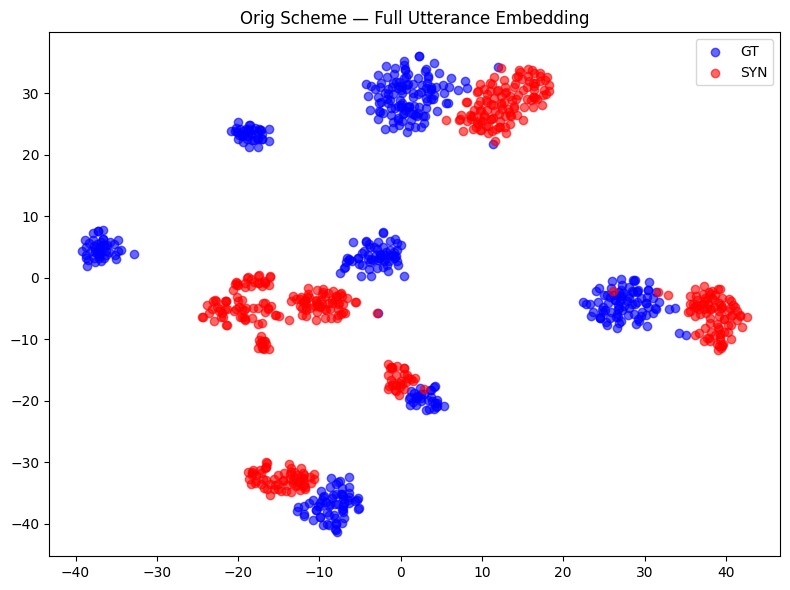

In [14]:
# Full utterance
visualize_full_utt(
    "/data2/minh_duc/neutts_eval/dis_drift1000/orig_gap_1000.npz",
    title="Orig Scheme — Full Utterance Embedding",
    save_path="./orig_full.png"
)

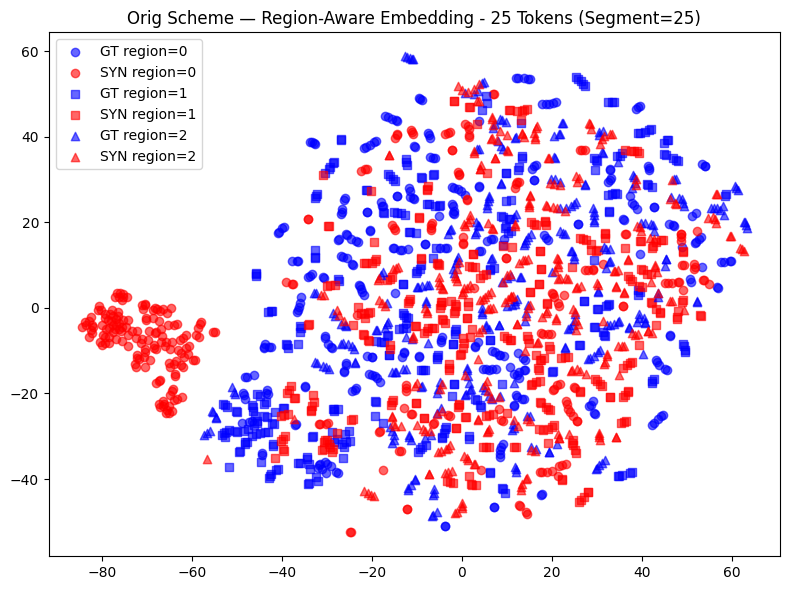

In [12]:
# Segment size 25 — region mode
visualize_segments(
    "/data2/minh_duc/neutts_eval/dis_drift/orig_gap.npz",
    segment_size="25",
    mode="region",
    title="Orig Scheme — Region-Aware Embedding - 25 Tokens",
    save_path="./orig_seg25_region.png"
)

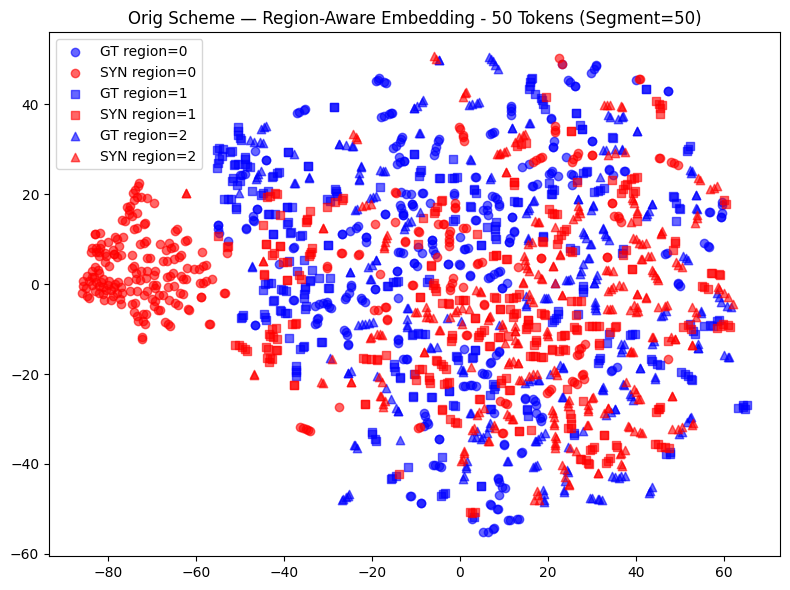

In [9]:
# Segment size 25 — region mode
visualize_segments(
    "/data2/minh_duc/neutts_eval/dis_drift/orig_gap.npz",
    segment_size="50",
    mode="region",
    title="Orig Scheme — Region-Aware Embedding - 50 Tokens",
    save_path="./orig_seg50_region.png"
)

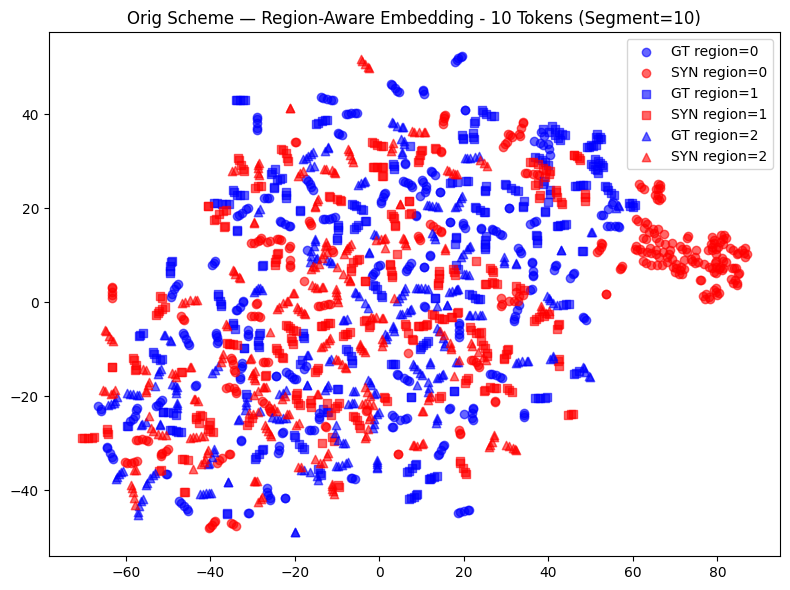

In [10]:
# Segment size 10 — region mode
visualize_segments(
    "/data2/minh_duc/neutts_eval/dis_drift/orig_gap.npz",
    segment_size="10",
    mode="region",
    title="Orig Scheme — Region-Aware Embedding - 10 Tokens",
    save_path="./orig_seg10_region.png"
)